In [1]:
CACHE_seq = "AVGACVLCNSQTSLRCGACIRRPFLCCKCCYDHVISTSHKLVLSVNPYVCNAPGCDVTDVTQLYLGGMSYYCKSHKPPISFPLCANGQVFGLYKNTCVGSDNVTDFNAIATCDWTNAGDYILANTCTERLKLFAAETLKATEETFKLSYGIATVREVLSDRELHLSWEVGKPRPPLNRNYVFTGYRVTKNSKVQIGEYTFEKGDYGDAVVYRGTTTYKLNVGDYFVLTSHTVMPLSAPTLVPQEHYVRITGLYPTLNISDEFSSNVANYQKVGMQKYSTLQGPPGTGKSHFAIGLALYYPSARIVYTACSHAAVDALCEKALKYLPIDKCSRIIPARARVECFDKFKVNSTLEQYVFCTVNALPETTADIVVFDEISMATNYDLSVVNARLRAKHYVYIGDPAQLPAPRTLLTKGTLEPEYFNSVCRLMKTIGPDMFLGTCRRCPAEIVDTVSALVYDNKLKAHKDKSAQCFKMFYKGVITHDVSSAINRPQIGVVREFLTRNPAWRKAVFISPYNSQNAVASKILGLPTQTVDSSQGSEYDYVIFTQTTETAHSCNVNRFNVAITRAKVGILCIMSDRDLYDKLQFTSLEIPRRNVATLQ"
protein_seq = "MVTPEGNVSLVDESLLVGVTDEDRAVRSAHQFYERLIGLWAPAVMEAAHELGVFAALAEAPADSGELARRLDCDARAMRVLLDALYAYDVIDRIHDTNGFRYLLSAEARECLLPGTLFSLVGKFMHDINVAWPAWRNLAEVVRHGARDTSGAESPNGIAQEDYESLVGGINFWAPPIVTTLSRKLRASGRSGDATASVLDVGCGTGLYSQLLLREFPRWTATGLDVERIATLANAQALRLGVEERFATRAGDFWRGGWGTGYDLVLFANIFHLQTPASAVRLMRHAAACLAPDGLVAVVDQIVDADREPKTPQDRFALLFAASMTNTGGGDAYTFQEYEEWFTAAGLQRIETLDTPMHRILLARRATEPSAVPEGQASENLYFQ"

print("len(CACHE_seq):", len(CACHE_seq))
print("len(protein_seq):", len(protein_seq))

len(CACHE_seq): 601
len(protein_seq): 384


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def stat(sample="CACHE_*_memory_usage*_s2.txt"):

    input_dir = "../output_stat"
    file_pattern = os.path.join(input_dir, sample)
    files = sorted(glob.glob(file_pattern))
    
    records = []
    
    for filepath in files:

        meta = {}
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:

                    break
                if ':' in line:
                    key, val = line.split(':', 1)
                    meta[key.strip()] = val.strip()

        basename = os.path.basename(filepath)
        label = basename.split("_memory_usage")[0]
        meta['label'] = label
    
        meta['batch_size'] = int(meta.get('batch_size', label) if 'batch_size' in meta else label)
        meta['peak_allocated_gb'] = float(meta['peak_allocated_bytes']) / 1e9
        meta['peak_reserved_gb'] = float(meta['peak_reserved_bytes']) / 1e9
        meta['predict_time_s'] = float(meta['predict_time_s'])
        
        records.append(meta)
    
    df = pd.DataFrame.from_records(records, 
        columns=['label', 'batch_size', 'peak_allocated_gb', 'peak_reserved_gb', 'predict_time_s'])
    df = df.sort_values('batch_size').reset_index(drop=True)
    
    baseline = df.loc[df['batch_size'] == 1, 'predict_time_s'].iloc[0]
    df['time_improvement_pct'] = ((baseline - df['predict_time_s']) / baseline) * 100
    df['time_improvement_pct'] = df['time_improvement_pct'].round(2)
    
    print(df.to_string(index=False))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].bar(df['label'], df['peak_allocated_gb'])
    axes[0].set_title('Peak Allocated (GB)')
    axes[0].set_xlabel('Run')
    axes[0].set_ylabel('GB')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(df['label'], df['peak_reserved_gb'])
    axes[1].set_title('Peak Reserved (GB)')
    axes[1].set_xlabel('Run')
    axes[1].tick_params(axis='x', rotation=45)
    
    axes[2].bar(df['label'], df['predict_time_s'])
    axes[2].set_title('Predict Time (s)')
    axes[2].set_xlabel('Run')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def gpu(sample="CACHE_*_memory_usage*_s2.txt", mode="Structure prediction"):

    input_dir = "../output_stat"
    file_pattern = os.path.join(input_dir, sample)
    files = sorted(glob.glob(file_pattern))
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for ax, filepath in zip(axes, files):

        with open(filepath, 'r') as f:
            lines = f.readlines()
        for i, line in enumerate(lines):
            if line.strip() == "timestamp,utilization":
                header_row = i
                break

        df = pd.read_csv(filepath, skiprows=header_row)

        t0 = df['timestamp'].iloc[0]
        df['t_rel'] = df['timestamp'] - t0

        label = os.path.basename(filepath).split("_memory_usage")[0]

        ax.plot(df['t_rel'], df['utilization'], marker='o', linewidth=1)
        ax.set_title(f"{mode} {label}")
        ax.set_xlabel("Время от начала, с")
        ax.set_ylabel("GPU, %")
        ax.set_ylim(0, 100)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    for ax in axes[len(files):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


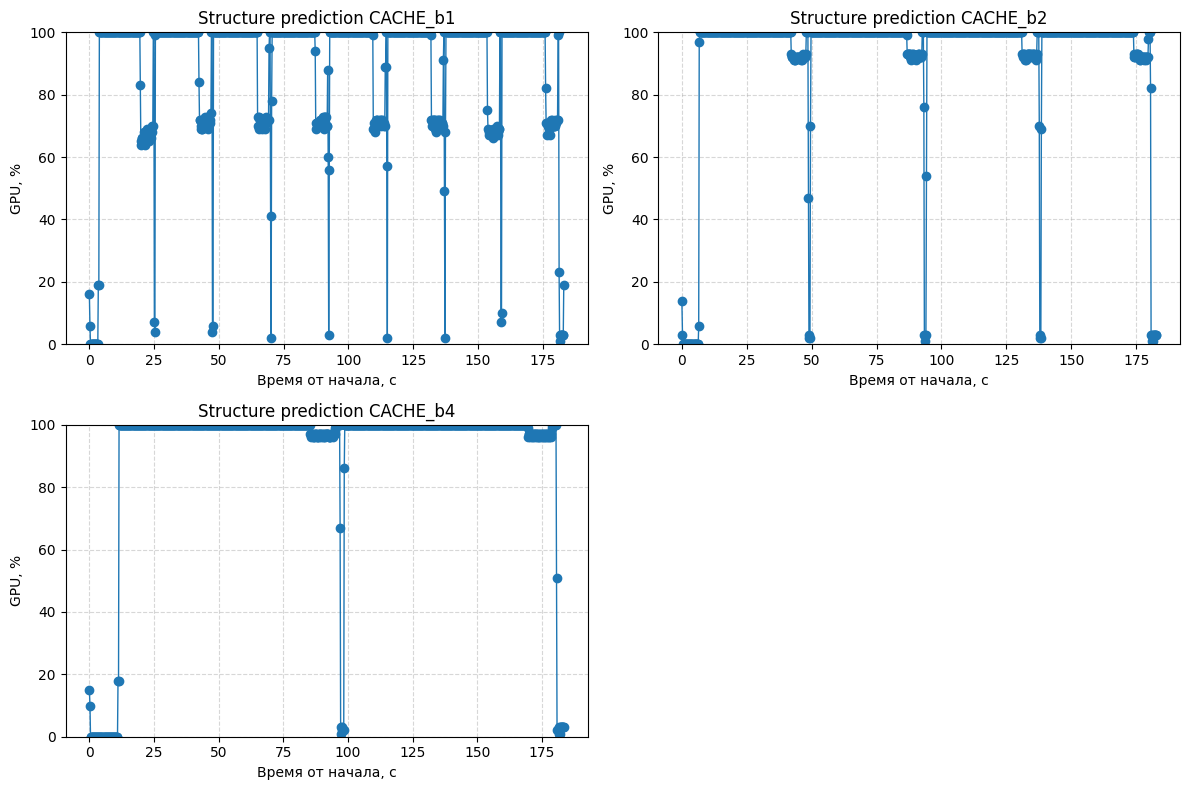

   label  batch_size  peak_allocated_gb  peak_reserved_gb  predict_time_s  time_improvement_pct
CACHE_b1           1           9.925776         19.677577         183.106                  0.00
CACHE_b2           2          21.194131         43.165680         182.870                  0.13
CACHE_b4           4          38.540051         65.097695         183.671                 -0.31


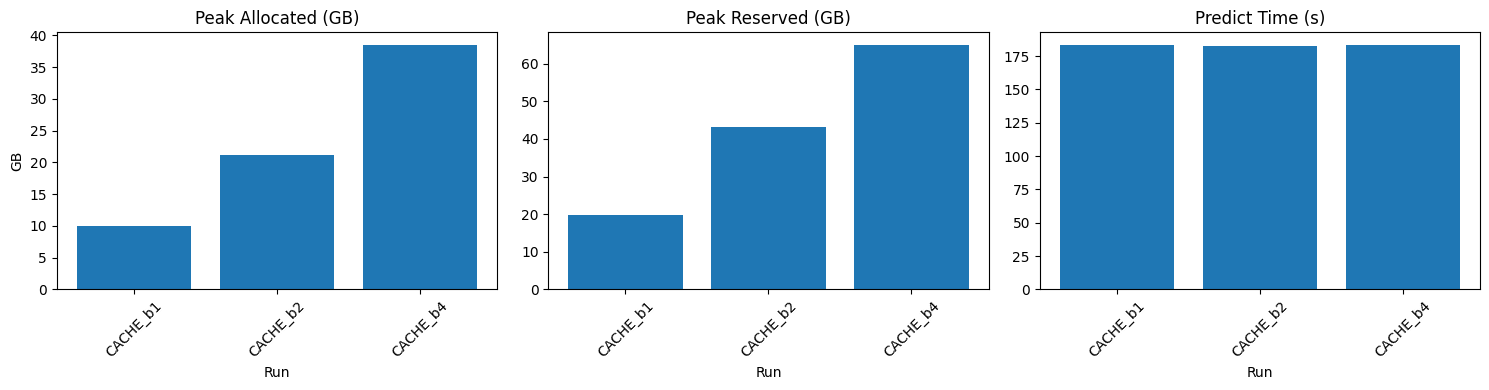

In [4]:
gpu(sample="CACHE_*_memory_usage*_s2.txt", mode="Structure prediction")
stat(sample="CACHE_*_memory_usage*_s2.txt")

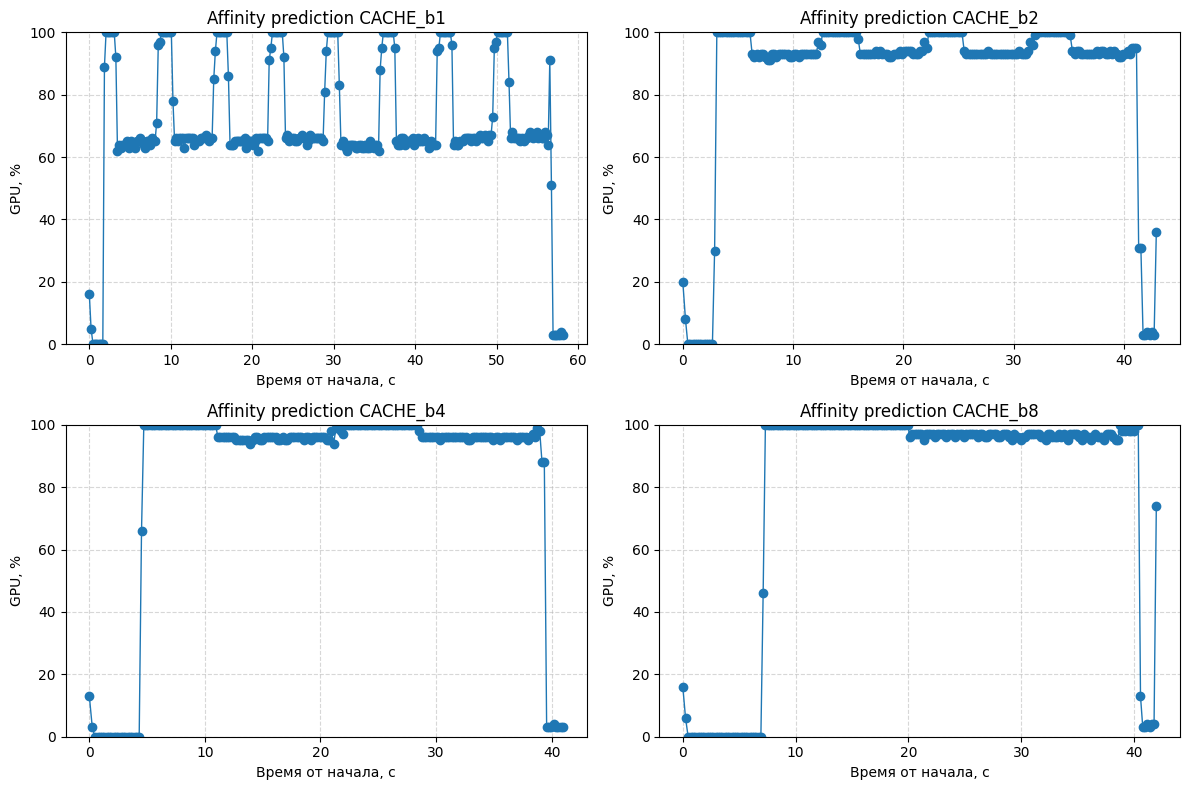

   label  batch_size  peak_allocated_gb  peak_reserved_gb  predict_time_s  time_improvement_pct
CACHE_b1           1           8.736893         20.428358          58.240                  0.00
CACHE_b2           2          15.376793         28.955378          42.974                 26.21
CACHE_b4           4          28.657667         55.725523          41.013                 29.58
CACHE_b8           8          55.215550         68.251812          41.978                 27.92


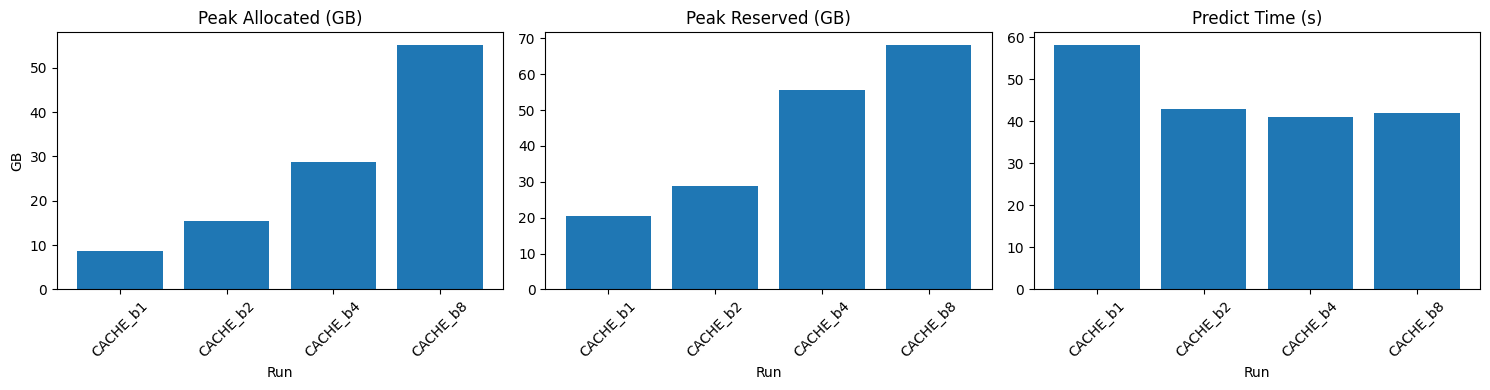

In [5]:
gpu(sample="CACHE_*_memory_usage*_s3.txt", mode="Affinity prediction")
stat(sample="CACHE_*_memory_usage*_s3.txt")

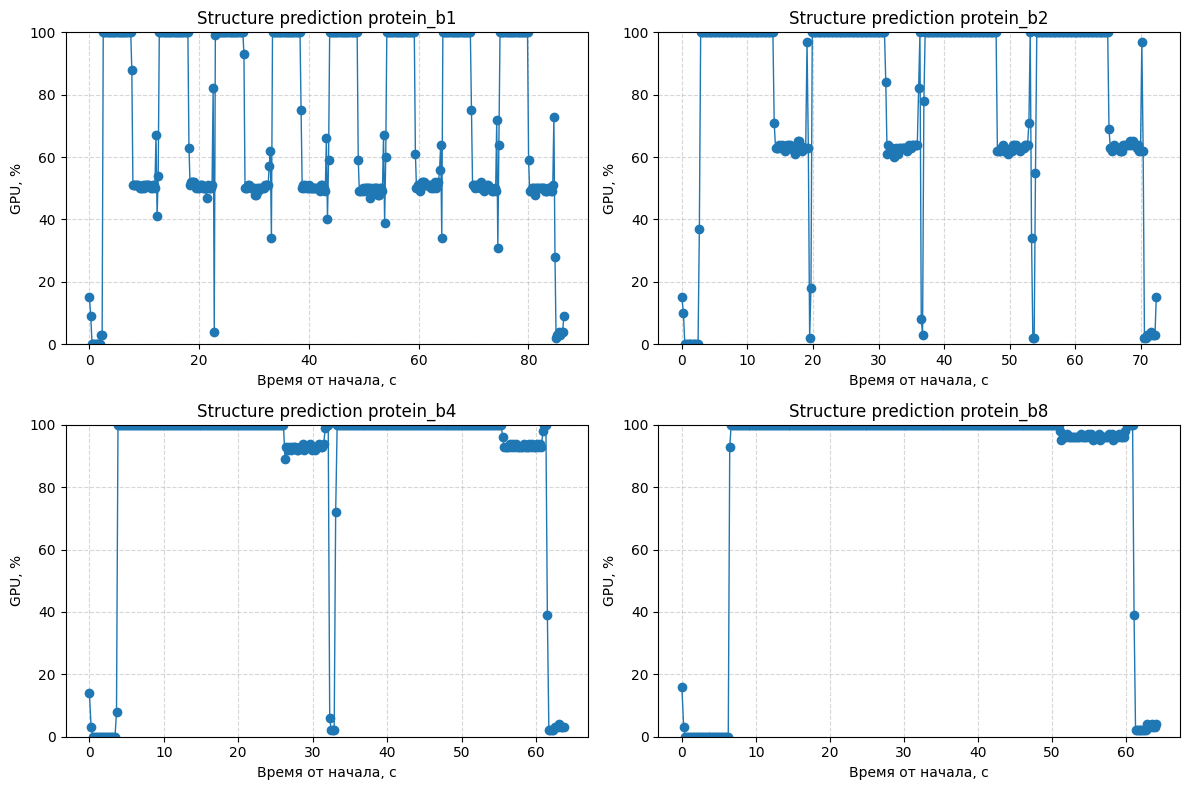

     label  batch_size  peak_allocated_gb  peak_reserved_gb  predict_time_s  time_improvement_pct
protein_b1           1           4.371971          6.599737          86.465                  0.00
protein_b2           2           7.677430         10.798236          72.425                 16.24
protein_b4           4          12.528054         18.033410          63.873                 26.13
protein_b8           8          22.239057         33.780924          64.281                 25.66


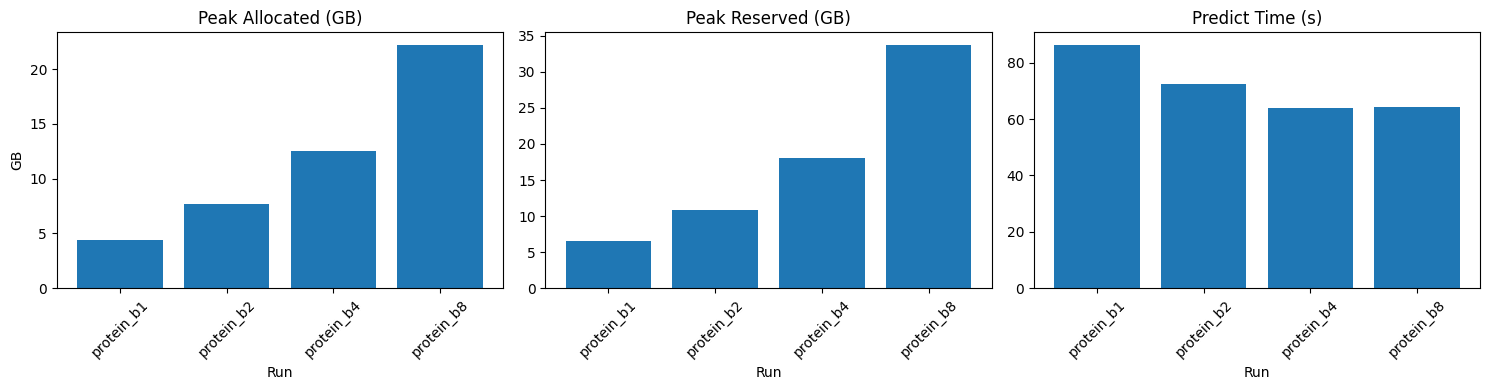

In [6]:
gpu(sample="protein_*_memory_usage*_s2.txt", mode="Structure prediction")
stat(sample="protein_*_memory_usage*_s2.txt")

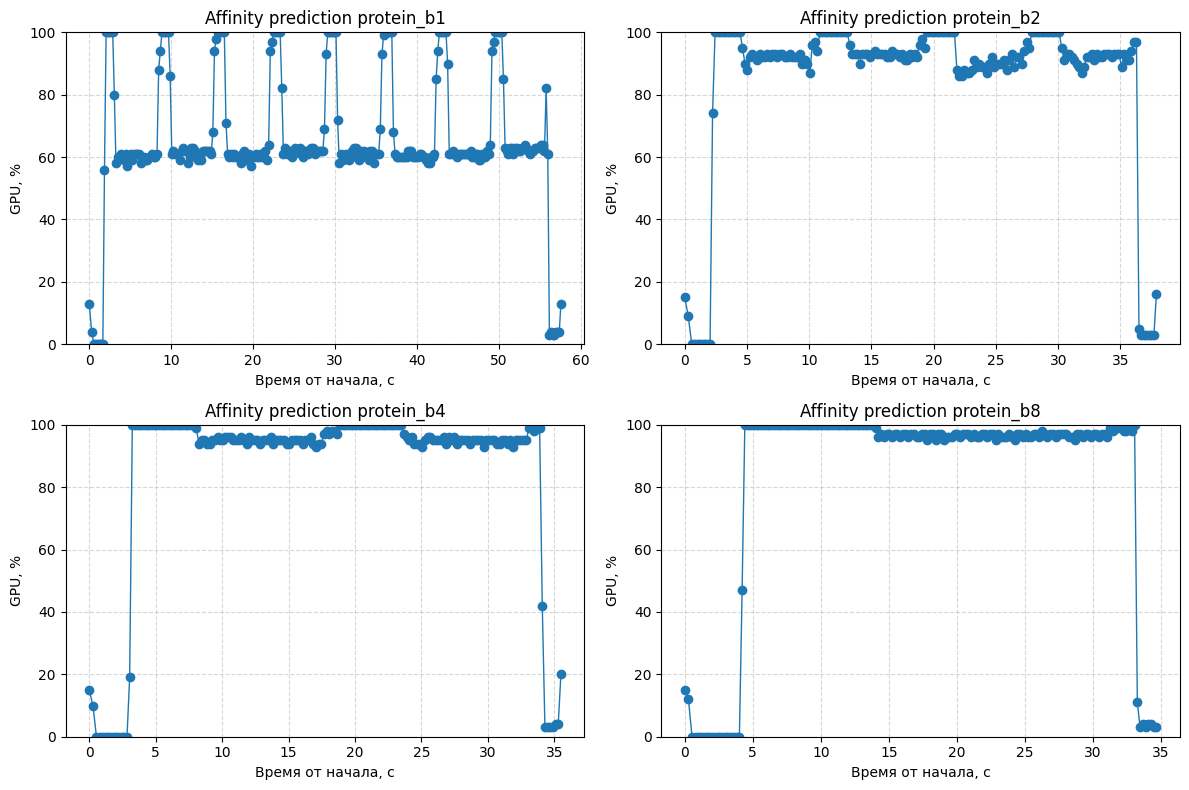

     label  batch_size  peak_allocated_gb  peak_reserved_gb  predict_time_s  time_improvement_pct
protein_b1           1           4.584501          9.028239          57.557                  0.00
protein_b2           2           7.071136         12.171870          37.938                 34.09
protein_b4           4          12.048007         14.803796          35.577                 38.19
protein_b8           8          22.000069         27.267170          34.727                 39.67


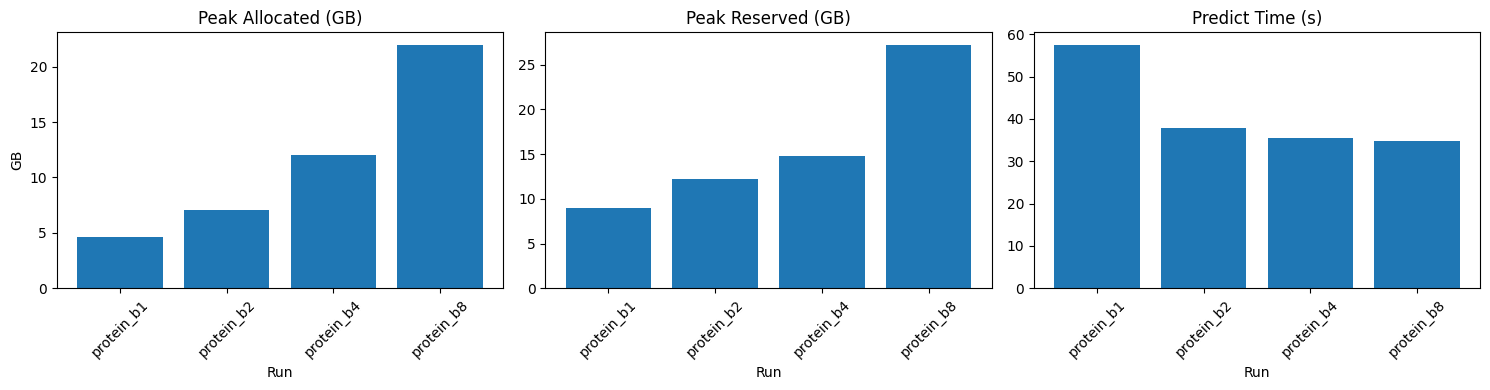

In [7]:
gpu(sample="protein_*_memory_usage*_s3.txt", mode="Affinity prediction")
stat(sample="protein_*_memory_usage*_s3.txt")